In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

# 1) Folder setup (data in / outputs out)
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")

DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)


# 2) Helper functions
def clean_zip(value):
    """
    Convert a ZIP value into a clean 5-digit ZIP string.
    Returns np.nan if the value is missing or invalid.

    Handles:
    - floats like 90012.0
    - ZIP+4 like "90012-1234"
    - short ZIPs like "123" -> "00123"
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip()

    # Remove trailing ".0" if it came in as a float (common in CSVs)
    if s.endswith(".0"):
        s = s[:-2]

    # If ZIP+4 format, keep only the first 5 digits
    if "-" in s:
        s = s.split("-", 1)[0]

    # Keep only digits (in case of weird formatting like "90012 ")
    if not s.isdigit():
        return np.nan

    # Pad to 5 digits (e.g., "123" -> "00123")
    return s.zfill(5)


def find_first_col(df, candidates):
    """
    Find the first column in df that matches one of the candidate names
    (case-insensitive). Returns the actual column name or None.
    """
    # Map lowercase column name -> actual column name
    lower_to_actual = {col.lower(): col for col in df.columns}

    for name in candidates:
        key = name.lower()
        if key in lower_to_actual:
            return lower_to_actual[key]

    return None


def coerce_date(df, date_col):
    """
    Convert a date column into real datetime values.
    Invalid dates become NaT (missing).
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    return df


def snapshot_asof(df, zip_col="zip", date_col="date", asof="2023-05-31"):
    """
    For each ZIP, keep the most recent row where date <= asof.
    Useful when you have daily/weekly time series data and want a single snapshot.

    Steps:
    1) Drop rows missing ZIP or date
    2) Keep only rows on/before the asof date
    3) For each ZIP, take the latest (max) date row
    """
    asof = pd.Timestamp(asof)

    # Work on a clean copy
    df = df.copy()

    # Drop rows missing ZIP/date
    df = df.dropna(subset=[zip_col, date_col])

    # Keep only rows up to the asof date
    df = df[df[date_col] <= asof]

    # Sort so the latest date per ZIP is at the bottom
    df = df.sort_values([zip_col, date_col])

    # Take the last row per ZIP (latest date)
    latest_per_zip = df.groupby(zip_col, as_index=False).tail(1)

    return latest_per_zip.reset_index(drop=True)

In [2]:
DATADESK_URL = "https://raw.githubusercontent.com/datadesk/california-coronavirus-data/master/cdph-vaccination-zipcode-totals.csv"
datadesk_raw = pd.read_csv(DATADESK_URL)

datadesk_raw.shape, datadesk_raw.head(3)

((143988, 11),
          date     id       county  fips  population  partially_vaccinated  \
 0  2021-08-17  90005  Los Angeles    37     39479.0                  3436   
 1  2021-08-17  90007  Los Angeles    37     41716.0                  3659   
 2  2021-08-17  90019  Los Angeles    37     66245.0                  5182   
 
    at_least_one_dose  fully_vaccinated  partially_vaccinated_percent  \
 0              26255             22819                          0.09   
 1              30782             27123                          0.09   
 2              42474             37292                          0.08   
 
    at_least_one_dose_percent  fully_vaccinated_percent  
 0                       0.67                      0.58  
 1                       0.74                      0.65  
 2                       0.64                      0.56  )

In [3]:
datadesk = datadesk_raw.copy()

# ZIP code (id column)
datadesk["zip"] = datadesk["id"].astype(str).str.zfill(5)

# Convert date column
datadesk["date"] = pd.to_datetime(datadesk["date"])

datadesk.head()

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip
0,2021-08-17,90005,Los Angeles,37,39479.0,3436,26255,22819,0.09,0.67,0.58,90005
1,2021-08-17,90007,Los Angeles,37,41716.0,3659,30782,27123,0.09,0.74,0.65,90007
2,2021-08-17,90019,Los Angeles,37,66245.0,5182,42474,37292,0.08,0.64,0.56,90019
3,2021-08-17,90024,Los Angeles,37,50288.0,2386,25869,23483,0.05,0.51,0.47,90024
4,2021-08-17,90025,Los Angeles,37,47967.0,2774,33549,30775,0.06,0.70,0.64,90025


In [4]:
datadesk["county"].unique()

array(['Los Angeles', 'Orange', 'Ventura', 'San Bernardino', 'San Diego',
       'Riverside', 'Santa Barbara', 'Kern', 'Fresno', 'San Mateo',
       'Santa Clara', 'San Francisco', 'Contra Costa', 'Alameda', 'Marin',
       'Santa Cruz', 'San Joaquin', 'Stanislaus', 'Sacramento', 'Placer',
       'El Dorado', 'Imperial', 'Kings', 'Tulare', 'San Luis Obispo',
       'Madera', 'Merced', 'Monterey', 'Napa', 'Solano', 'Sonoma',
       'San Benito', 'Calaveras', 'Tuolumne', 'Mendocino', 'Lake',
       'Humboldt', 'Del Norte', 'Yolo', 'Yuba', 'Butte', 'Nevada',
       'Sutter', 'Shasta', 'Tehama', 'Inyo', 'Mono', 'Amador', 'Siskiyou',
       'Mariposa', 'Glenn', 'Lassen', 'Colusa', 'Modoc', 'Plumas',
       'Alpine', 'Trinity', 'Sierra'], dtype=object)

In [5]:
datadesk_la = datadesk[datadesk["county"] == "Los Angeles"].copy()

print("Rows:", len(datadesk_la))
print("Unique ZIPs:", datadesk_la["zip"].nunique())

Rows: 25618
Unique ZIPs: 276


start = pd.Timestamp("2021-08-01")
end = pd.Timestamp("2023-05-31")

datadesk_la = datadesk_la[
    (datadesk_la["date"] >= start) &
    (datadesk_la["date"] <= end)
].copy()

datadesk_la["date"].min(), datadesk_la["date"].max()

datadesk_la = datadesk_la.sort_values(["zip", "date"])

datadesk_snapshot = (
    datadesk_la
    .groupby("zip", as_index=False)
    .tail(1)
)
datadesk_snapshot = datadesk_snapshot.copy()
#you can increase or decrease the number from 20 if you wanna view more data
datadesk_snapshot.tail(50)

In [6]:
datadesk_la["date"].dt.year.value_counts().sort_index()

date
2021     5196
2022    14350
2023     6072
Name: count, dtype: int64

In [7]:
datadesk_la["date"].unique()

<DatetimeArray>
['2021-08-17 00:00:00', '2021-08-24 00:00:00', '2021-08-31 00:00:00',
 '2021-09-07 00:00:00', '2021-09-14 00:00:00', '2021-09-21 00:00:00',
 '2021-09-28 00:00:00', '2021-10-05 00:00:00', '2021-10-12 00:00:00',
 '2021-10-19 00:00:00', '2021-10-26 00:00:00', '2021-11-02 00:00:00',
 '2021-11-09 00:00:00', '2021-11-16 00:00:00', '2021-11-23 00:00:00',
 '2021-11-30 00:00:00', '2021-12-07 00:00:00', '2021-12-14 00:00:00',
 '2021-12-21 00:00:00', '2021-12-28 00:00:00', '2022-01-04 00:00:00',
 '2022-01-11 00:00:00', '2022-01-18 00:00:00', '2022-01-25 00:00:00',
 '2022-02-01 00:00:00', '2022-02-08 00:00:00', '2022-02-15 00:00:00',
 '2022-02-22 00:00:00', '2022-03-01 00:00:00', '2022-03-08 00:00:00',
 '2022-03-15 00:00:00', '2022-03-22 00:00:00', '2022-03-29 00:00:00',
 '2022-04-05 00:00:00', '2022-04-12 00:00:00', '2022-04-19 00:00:00',
 '2022-04-26 00:00:00', '2022-05-03 00:00:00', '2022-05-10 00:00:00',
 '2022-05-17 00:00:00', '2022-05-24 00:00:00', '2022-05-31 00:00:00',
 '20

In [8]:
# Convert fully_vaccinated_percent to numeric
datadesk_la["vax_rate"] = pd.to_numeric(
    datadesk_la["fully_vaccinated_percent"],
    errors="coerce"
)

# Remove infinite values safely
datadesk_la["vax_rate"] = datadesk_la["vax_rate"].replace([np.inf, -np.inf], np.nan)

# Check the result
datadesk_la["vax_rate"].describe()

count    25536.000000
mean         0.731369
std          0.118579
min          0.240000
25%          0.670000
50%          0.730000
75%          0.780000
max          1.660000
Name: vax_rate, dtype: float64

In [9]:
datadesk_la["id"].unique()

array([90005, 90007, 90019, 90024, 90025, 90027, 90028, 90034, 90035,
       90036, 90042, 90045, 90046, 90048, 90049, 90064, 90066, 90068,
       90069, 90077, 90201, 90210, 90212, 90254, 90255, 90265, 90266,
       90272, 90274, 90275, 90277, 90278, 90291, 90292, 90403, 90503,
       90505, 90650, 90703, 90706, 90717, 90803, 90805, 90808, 90815,
       91001, 91006, 91011, 91016, 91106, 91301, 91302, 91304, 91316,
       91335, 91342, 91344, 91350, 91356, 91364, 91367, 91403, 91405,
       91423, 91436, 91604, 91702, 91744, 91745, 91748, 91766, 91770,
       91776, 91789, 93536, 90001, 90002, 90003, 90004, 90006, 90008,
       90011, 90012, 90013, 90015, 90016, 90017, 90018, 90020, 90022,
       90023, 90026, 90029, 90031, 90032, 90033, 90037, 90038, 90039,
       90041, 90043, 90044, 90047, 90057, 90059, 90062, 90063, 90065,
       90067, 90094, 90211, 90220, 90221, 90222, 90230, 90232, 90240,
       90241, 90242, 90245, 90247, 90249, 90250, 90260, 90262, 90280,
       90290, 90293,

In [10]:
datadesk_la

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip,vax_rate
0,2021-08-17,90005,Los Angeles,37,39479.0,3436,26255,22819,0.09,0.67,0.58,90005,0.58
1,2021-08-17,90007,Los Angeles,37,41716.0,3659,30782,27123,0.09,0.74,0.65,90007,0.65
2,2021-08-17,90019,Los Angeles,37,66245.0,5182,42474,37292,0.08,0.64,0.56,90019,0.56
3,2021-08-17,90024,Los Angeles,37,50288.0,2386,25869,23483,0.05,0.51,0.47,90024,0.47
4,2021-08-17,90025,Los Angeles,37,47967.0,2774,33549,30775,0.06,0.70,0.64,90025,0.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...
143147,2023-05-30,93550,Los Angeles,37,77006.0,5170,54215,49045,0.07,0.70,0.64,93550,0.64
143148,2023-05-30,93551,Los Angeles,37,51085.0,2921,39150,36229,0.06,0.77,0.71,93551,0.71
143149,2023-05-30,93552,Los Angeles,37,40266.0,2503,30546,28043,0.06,0.76,0.70,93552,0.70
143150,2023-05-30,93553,Los Angeles,37,1781.0,100,1061,961,0.06,0.60,0.54,93553,0.54


In [11]:
datadesk_la.describe()

,date,id,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,vax_rate
count,25618,25618.000000,25618.0,25618.000000,25618.000000,25618.000000,25618.000000,25618.00,25618.00,25618.00,25536.000000
mean,2022-07-12 11:30:09.134202880,90892.870755,37.0,36698.797759,2740.346865,28872.053010,26131.706144,inf,inf,inf,0.731369
min,2021-08-17 00:00:00,90001.000000,37.0,0.000000,11.000000,139.000000,128.000000,0.02,0.30,0.24,0.240000
25%,2022-02-01 00:00:00,90221.000000,37.0,22892.000000,1502.000000,18963.750000,17157.250000,0.06,0.74,0.67,0.670000
50%,2022-07-12 00:00:00,90744.000000,37.0,33058.000000,2285.000000,26427.500000,24240.000000,0.07,0.80,0.73,0.730000
75%,2022-12-20 00:00:00,91364.000000,37.0,47438.000000,3458.000000,37203.750000,33741.500000,0.08,0.86,0.79,0.780000
max,2023-05-30 00:00:00,93591.000000,37.0,109414.000000,15483.000000,85612.000000,76941.000000,inf,inf,inf,1.660000
std,NaN,822.849583,0.0,21058.390705,1951.066283,15763.023744,14106.918323,NaN,NaN,NaN,0.118579


In [12]:
#finding infinite values
datadesk_la['fully_vaccinated_percent'].max()

inf

In [13]:
#identify how many rows
np.isinf(datadesk_la['fully_vaccinated_percent']).sum()

82

In [14]:
#eliminated inifite value row
datadesk_la['fully_vaccinated_percent'] = datadesk_la['fully_vaccinated_percent'].replace([np.inf, -np.inf], np.nan)

In [15]:
datadesk_la['fully_vaccinated_percent'].max()

1.66

In [16]:
datadesk_la["date"].unique()

<DatetimeArray>
['2021-08-17 00:00:00', '2021-08-24 00:00:00', '2021-08-31 00:00:00',
 '2021-09-07 00:00:00', '2021-09-14 00:00:00', '2021-09-21 00:00:00',
 '2021-09-28 00:00:00', '2021-10-05 00:00:00', '2021-10-12 00:00:00',
 '2021-10-19 00:00:00', '2021-10-26 00:00:00', '2021-11-02 00:00:00',
 '2021-11-09 00:00:00', '2021-11-16 00:00:00', '2021-11-23 00:00:00',
 '2021-11-30 00:00:00', '2021-12-07 00:00:00', '2021-12-14 00:00:00',
 '2021-12-21 00:00:00', '2021-12-28 00:00:00', '2022-01-04 00:00:00',
 '2022-01-11 00:00:00', '2022-01-18 00:00:00', '2022-01-25 00:00:00',
 '2022-02-01 00:00:00', '2022-02-08 00:00:00', '2022-02-15 00:00:00',
 '2022-02-22 00:00:00', '2022-03-01 00:00:00', '2022-03-08 00:00:00',
 '2022-03-15 00:00:00', '2022-03-22 00:00:00', '2022-03-29 00:00:00',
 '2022-04-05 00:00:00', '2022-04-12 00:00:00', '2022-04-19 00:00:00',
 '2022-04-26 00:00:00', '2022-05-03 00:00:00', '2022-05-10 00:00:00',
 '2022-05-17 00:00:00', '2022-05-24 00:00:00', '2022-05-31 00:00:00',
 '20

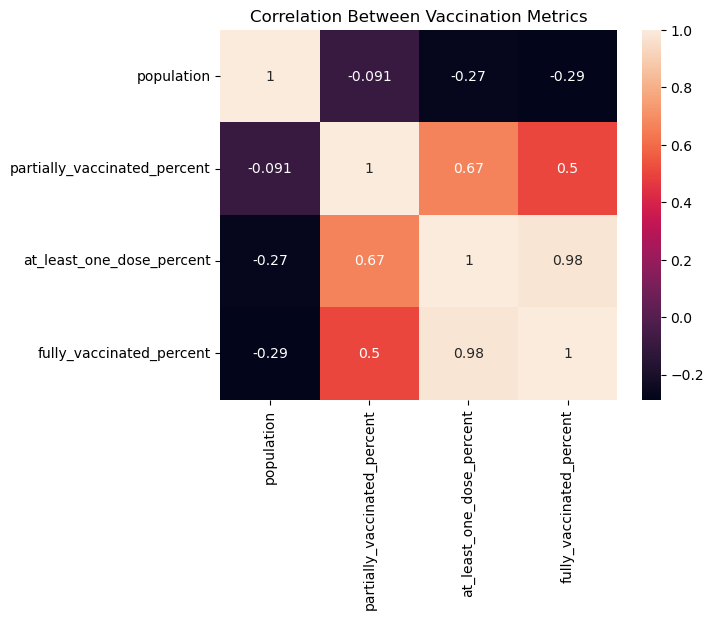

In [17]:
corr = datadesk_la[[
    'population',
    'partially_vaccinated_percent',
    'at_least_one_dose_percent',
    'fully_vaccinated_percent'
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Between Vaccination Metrics")
plt.show()

In [18]:
#Setting fully vaccinated max as 100%
datadesk_la['fully_vaccinated_percent'] = datadesk_la['fully_vaccinated_percent'].clip(upper=1)

In [19]:
#converting fully vaccinated to percentage
datadesk_la['fully_vaccinated_percent'] = datadesk_la['fully_vaccinated_percent'] * 100

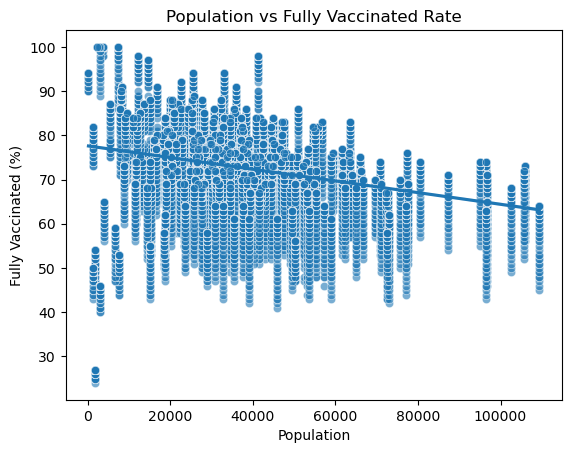

In [20]:
sns.scatterplot(
    data=datadesk_la,
    x='population',
    y='fully_vaccinated_percent',
    alpha=0.6
)

sns.regplot(
    data=datadesk_la,
    x='population',
    y='fully_vaccinated_percent',
    scatter=False
)

plt.title("Population vs Fully Vaccinated Rate")
plt.xlabel("Population")
plt.ylabel("Fully Vaccinated (%)")
plt.show()



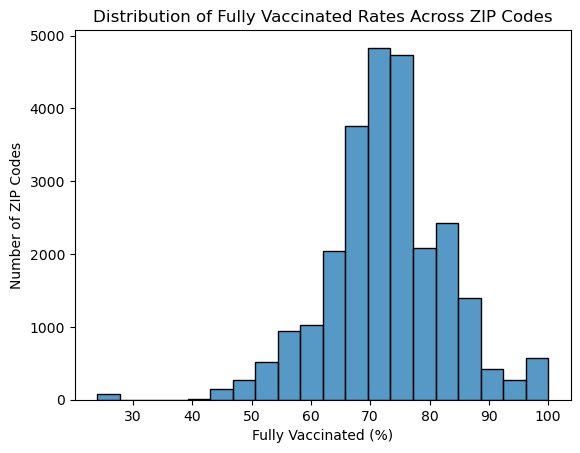

In [21]:
sns.histplot(
    data=datadesk_la,
    x='fully_vaccinated_percent',
    bins=20
)

plt.title("Distribution of Fully Vaccinated Rates Across ZIP Codes")
plt.xlabel("Fully Vaccinated (%)")
plt.ylabel("Number of ZIP Codes")
plt.show()

In [22]:
#maxxing at least one dose at 100
datadesk_la['at_least_one_dose_percent'] = datadesk_la['at_least_one_dose_percent'].clip(upper=1)

In [23]:
#converting at least one dose to percentage
datadesk_la['at_least_one_dose_percent'] = datadesk_la['at_least_one_dose_percent'] * 100

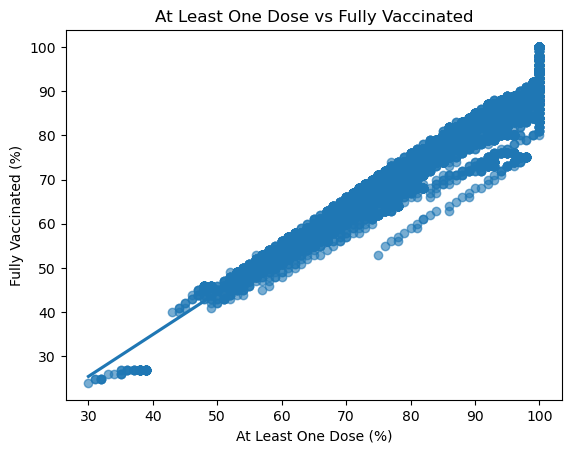

In [24]:
sns.regplot(
    data=datadesk_la,
    x='at_least_one_dose_percent',
    y='fully_vaccinated_percent',
    scatter_kws={'alpha':0.6}
)

plt.title("At Least One Dose vs Fully Vaccinated")
plt.xlabel("At Least One Dose (%)")
plt.ylabel("Fully Vaccinated (%)")
plt.show()

In [25]:
income_2023 = pd.read_csv("income_data/LA County Median Income 2023.csv")

In [26]:
income_2023

,Zip Code,Estimated Median Income
0,90001,"$60,751"
1,90002,"$56,158"
2,90003,"$54,781"
3,90004,"$62,655"
4,90005,"$52,755"
...,...,...
278,93551,"$110,850"
279,93552,"$84,894"
280,93553,"$73,029"
281,93563,"No 2023 estimate ($210,600 in 2021)†"


In [27]:
income_2021 = pd.read_csv("income_data/LA County Median Income Data - 2021.csv")

In [28]:
income_2021

,Zip Code,Estimated Median Income
0,90001,"$52,806"
1,90002,"$46,159"
2,90003,"$47,733"
3,90004,"$54,947"
4,90005,"$44,913"
...,...,...
277,93551,"$98,181"
278,93552,"$73,074"
279,93553,"$59,805"
280,93563,"$210,600"


income_2023 = income_2023.rename(columns={
    'Zip Code': 'zip',
    'Estimated Median Income': 'median_income_2023'
})
income_2023['zip'] = income_2023['zip'].astype(str)

income_2021 = income_2021.rename(columns={
    'Zip Code': 'zip',
    'Estimated Median Income': 'median_income_2021'
})
income_2021['zip'] = income_2021['zip'].astype(str)

In [29]:
datadesk_la['zip'] = datadesk_la['zip'].astype(str)

In [30]:
# Rename for consistency
income_2021 = income_2021.rename(columns={'Zip Code': 'zip', 'Estimated Median Income': 'median_income_2021'})
income_2023 = income_2023.rename(columns={'Zip Code': 'zip', 'Estimated Median Income': 'median_income_2023'})

In [31]:
# Ensure zip codes are strings
income_2021['zip'] = income_2021['zip'].astype(str)
income_2023['zip'] = income_2023['zip'].astype(str)

# Rename the income column for clarity
income_2021 = income_2021.rename(columns={'Estimated Median Income': 'median_income_2021'})
income_2023 = income_2023.rename(columns={'Estimated Median Income': 'median_income_2023'})

# Remove $ or commas and convert to numeric
for col in ['median_income_2021', 'median_income_2023']:
    if col in income_2021.columns:
        income_2021[col] = pd.to_numeric(income_2021[col].replace('[\$,]', '', regex=True), errors='coerce')
    if col in income_2023.columns:
        income_2023[col] = pd.to_numeric(income_2023[col].replace('[\$,]', '', regex=True), errors='coerce')

# Merge the datasets
snapshot_with_income = datadesk_la.merge(
    income_2021, how='left', on='zip'
).merge(
    income_2023, how='left', on='zip'
)

# Now create the 2022 median as average
snapshot_with_income['median_income_2022'] = (
    snapshot_with_income['median_income_2021'] + snapshot_with_income['median_income_2023']
) / 2

# Convert all three columns to numeric just to be safe
for col in ['median_income_2021', 'median_income_2022', 'median_income_2023']:
    snapshot_with_income[col] = pd.to_numeric(snapshot_with_income[col], errors='coerce')

In [32]:
# Ensure 'date' is datetime and extract year
snapshot_with_income['date'] = pd.to_datetime(snapshot_with_income['date'])
snapshot_with_income['year'] = snapshot_with_income['date'].dt.year

# Create a single 'median_income' column that picks the right year's income
snapshot_with_income['median_income'] = np.select(
    [
        snapshot_with_income['year'] == 2021,
        snapshot_with_income['year'] == 2022,
        snapshot_with_income['year'] == 2023
    ],
    [
        snapshot_with_income['median_income_2021'],
        snapshot_with_income['median_income_2022'],
        snapshot_with_income['median_income_2023']
    ],
    default=np.nan)


In [33]:
snapshot_with_income['date'] = pd.to_datetime(snapshot_with_income['date'])

In [34]:
snapshot_with_income['year'] = snapshot_with_income['date'].dt.year

In [35]:
snapshot_with_income[['zip','year','median_income_2021','median_income_2022','median_income_2023','median_income']].head(10)

,zip,year,median_income_2021,median_income_2022,median_income_2023,median_income
0,90005,2021,44913.0,48834.0,52755.0,44913.0
1,90007,2021,33222.0,34627.0,36032.0,33222.0
2,90019,2021,61616.0,66505.5,71395.0,61616.0
3,90024,2021,67422.0,73708.0,79994.0,67422.0
4,90025,2021,100453.0,102540.0,104627.0,100453.0
5,90027,2021,78356.0,84444.0,90532.0,78356.0
6,90028,2021,52814.0,56103.5,59393.0,52814.0
7,90034,2021,88490.0,95786.0,103082.0,88490.0
8,90035,2021,101570.0,104897.0,108224.0,101570.0
9,90036,2021,87868.0,95372.5,102877.0,87868.0


In [36]:
snapshot_with_income["date"].unique()

<DatetimeArray>
['2021-08-17 00:00:00', '2021-08-24 00:00:00', '2021-08-31 00:00:00',
 '2021-09-07 00:00:00', '2021-09-14 00:00:00', '2021-09-21 00:00:00',
 '2021-09-28 00:00:00', '2021-10-05 00:00:00', '2021-10-12 00:00:00',
 '2021-10-19 00:00:00', '2021-10-26 00:00:00', '2021-11-02 00:00:00',
 '2021-11-09 00:00:00', '2021-11-16 00:00:00', '2021-11-23 00:00:00',
 '2021-11-30 00:00:00', '2021-12-07 00:00:00', '2021-12-14 00:00:00',
 '2021-12-21 00:00:00', '2021-12-28 00:00:00', '2022-01-04 00:00:00',
 '2022-01-11 00:00:00', '2022-01-18 00:00:00', '2022-01-25 00:00:00',
 '2022-02-01 00:00:00', '2022-02-08 00:00:00', '2022-02-15 00:00:00',
 '2022-02-22 00:00:00', '2022-03-01 00:00:00', '2022-03-08 00:00:00',
 '2022-03-15 00:00:00', '2022-03-22 00:00:00', '2022-03-29 00:00:00',
 '2022-04-05 00:00:00', '2022-04-12 00:00:00', '2022-04-19 00:00:00',
 '2022-04-26 00:00:00', '2022-05-03 00:00:00', '2022-05-10 00:00:00',
 '2022-05-17 00:00:00', '2022-05-24 00:00:00', '2022-05-31 00:00:00',
 '20

In [37]:
snapshot_with_income.dtypes

date                            datetime64[ns]
id                                       int64
county                                  object
fips                                     int64
population                             float64
partially_vaccinated                     int64
at_least_one_dose                        int64
fully_vaccinated                         int64
partially_vaccinated_percent           float64
at_least_one_dose_percent              float64
fully_vaccinated_percent               float64
zip                                     object
vax_rate                               float64
median_income_2021                     float64
median_income_2023                     float64
median_income_2022                     float64
year                                     int32
median_income                          float64
dtype: object

In [38]:
# Convert all median income columns to numeric
for col in ['median_income_2021', 'median_income_2022', 'median_income_2023', 'median_income']:
    snapshot_with_income[col] = (
        snapshot_with_income[col]
        .replace('[\$,]', '', regex=True)  # remove $ and commas
    )
    snapshot_with_income[col] = pd.to_numeric(
        snapshot_with_income[col],
        errors='coerce'  # invalid entries become NaN
    )

In [39]:
snapshot_with_income['median_income'].dtype

dtype('float64')

In [40]:
#Checking for any weird values
snapshot_with_income['median_income'].describe()

count     25382.000000
mean      91171.019187
std       33018.914177
min       22291.000000
25%       66923.000000
50%       86583.000000
75%      106364.000000
max      222273.000000
Name: median_income, dtype: float64

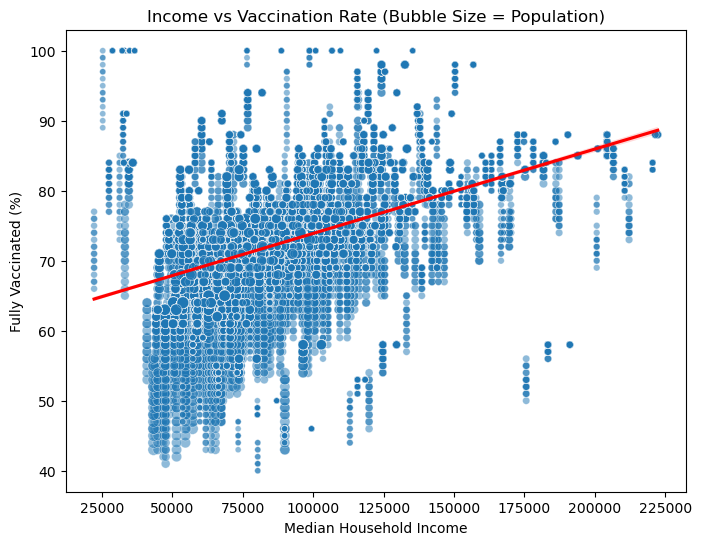

In [41]:
plt.figure(figsize=(8,6))

# Bubble scatter
sns.scatterplot(
    data=snapshot_with_income,
    x='median_income',
    y='fully_vaccinated_percent',
    size='population',
    alpha=0.5,
    legend=False
)

# Regression line
sns.regplot(
    data=snapshot_with_income,
    x='median_income',
    y='fully_vaccinated_percent',
    scatter=False,
    color='red'
)

plt.title("Income vs Vaccination Rate (Bubble Size = Population)")
plt.xlabel("Median Household Income")
plt.ylabel("Fully Vaccinated (%)")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

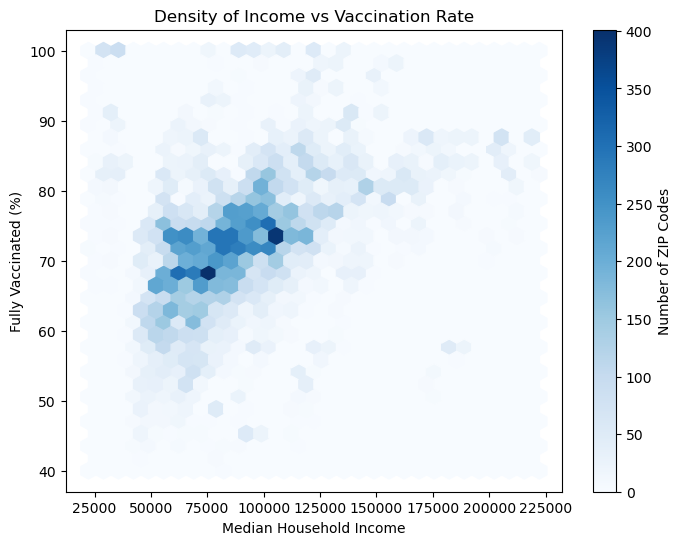

In [42]:
plt.figure(figsize=(8,6))

plt.hexbin(
    snapshot_with_income['median_income'],
    snapshot_with_income['fully_vaccinated_percent'],
    gridsize=30,
    cmap='Blues'
)

plt.colorbar(label='Number of ZIP Codes')

plt.title("Density of Income vs Vaccination Rate")
plt.xlabel("Median Household Income")
plt.ylabel("Fully Vaccinated (%)")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

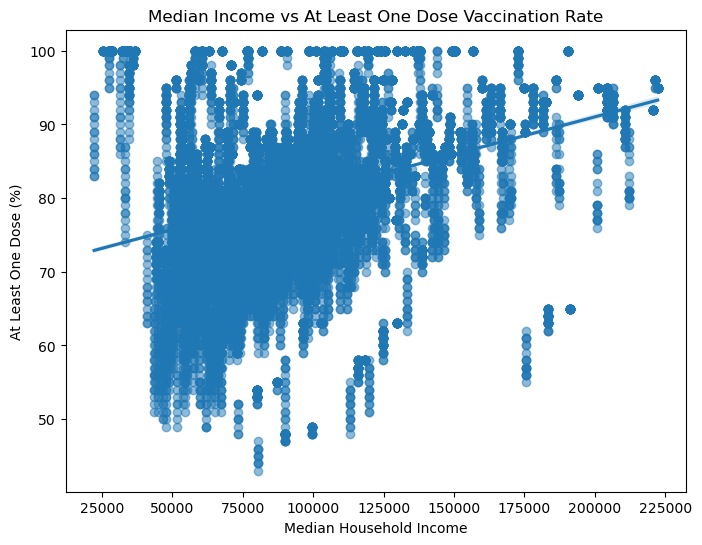

In [43]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=snapshot_with_income,
    x='median_income',
    y='at_least_one_dose_percent',
    scatter_kws={'alpha':0.5}
)

plt.title("Median Income vs At Least One Dose Vaccination Rate")
plt.xlabel("Median Household Income")
plt.ylabel("At Least One Dose (%)")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

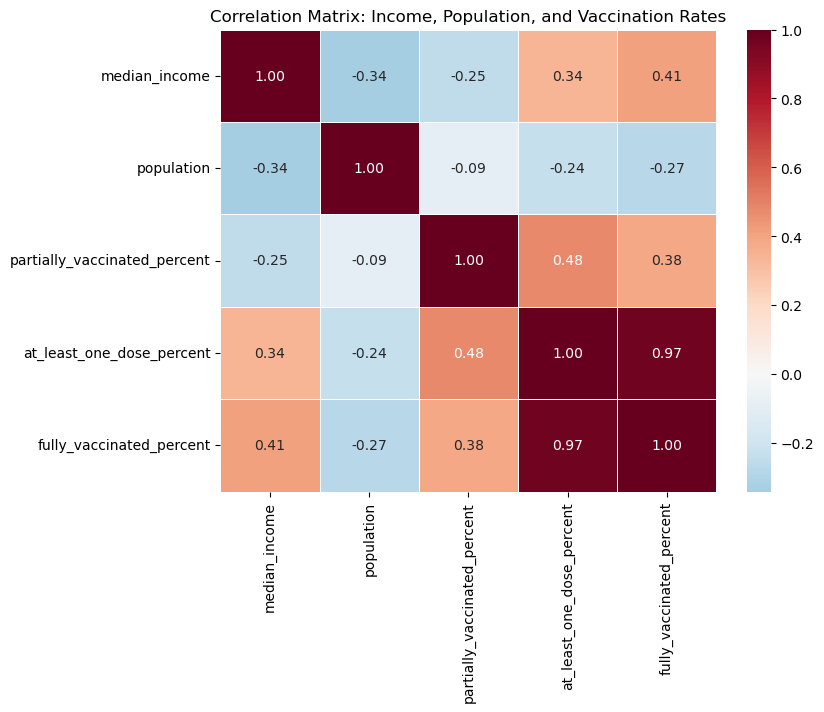

In [44]:
plt.figure(figsize=(8,6))

corr = snapshot_with_income[
    ['median_income',
     'population',
     'partially_vaccinated_percent',
     'at_least_one_dose_percent',
     'fully_vaccinated_percent']
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix: Income, Population, and Vaccination Rates")

plt.show()

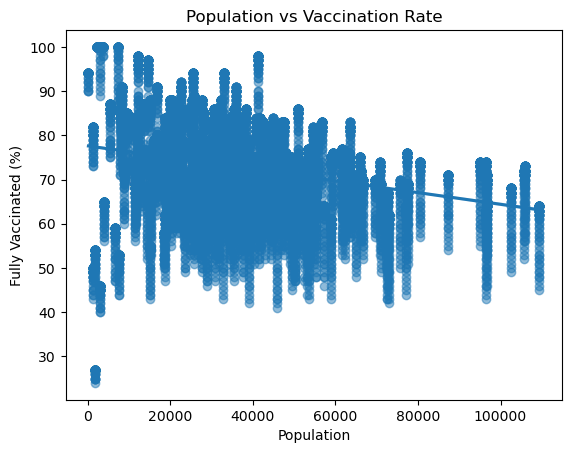

In [45]:
sns.regplot(
    data=snapshot_with_income,
    x='population',
    y='fully_vaccinated_percent',
    scatter_kws={'alpha':0.5}
)

plt.title("Population vs Vaccination Rate")
plt.xlabel("Population")
plt.ylabel("Fully Vaccinated (%)")
plt.show()

In [46]:
snapshot_with_income["zip"].unique()

array(['90005', '90007', '90019', '90024', '90025', '90027', '90028',
       '90034', '90035', '90036', '90042', '90045', '90046', '90048',
       '90049', '90064', '90066', '90068', '90069', '90077', '90201',
       '90210', '90212', '90254', '90255', '90265', '90266', '90272',
       '90274', '90275', '90277', '90278', '90291', '90292', '90403',
       '90503', '90505', '90650', '90703', '90706', '90717', '90803',
       '90805', '90808', '90815', '91001', '91006', '91011', '91016',
       '91106', '91301', '91302', '91304', '91316', '91335', '91342',
       '91344', '91350', '91356', '91364', '91367', '91403', '91405',
       '91423', '91436', '91604', '91702', '91744', '91745', '91748',
       '91766', '91770', '91776', '91789', '93536', '90001', '90002',
       '90003', '90004', '90006', '90008', '90011', '90012', '90013',
       '90015', '90016', '90017', '90018', '90020', '90022', '90023',
       '90026', '90029', '90031', '90032', '90033', '90037', '90038',
       '90039', '900

In [47]:
snapshot_with_income['zip'] = (
    snapshot_with_income['zip']
    .astype(str)
    .str.strip()
    .str.replace('.0','', regex=False)
)

In [48]:
zip_to_region = {
    # South LA
    '90001':'South LA','90002':'South LA','90003':'South LA','90004':'South LA',
    '90005':'South LA','90006':'South LA','90007':'South LA','90008':'South LA',
    '90010':'South LA','90011':'South LA','90012':'South LA','90013':'South LA',
    '90014':'South LA','90015':'South LA','90016':'South LA','90017':'South LA',
    '90018':'South LA','90019':'South LA','90020':'South LA','90021':'South LA',
    '90022':'South LA','90023':'South LA','90024':'South LA','90025':'South LA',
    '90026':'South LA','90027':'South LA','90028':'South LA','90029':'South LA',
    '90031':'South LA','90032':'South LA','90033':'South LA','90034':'South LA',
    '90035':'South LA','90036':'South LA','90037':'South LA','90038':'South LA',
    '90039':'South LA','90040':'South LA','90041':'South LA','90042':'South LA',
    '90043':'South LA','90044':'South LA','90045':'South LA','90046':'South LA',
    '90047':'South LA','90048':'South LA','90049':'South LA','90056':'South LA',
    '90057':'South LA','90058':'South LA','90059':'South LA','90061':'South LA',
    '90062':'South LA','90063':'South LA','90064':'South LA','90065':'South LA',
    '90066':'South LA','90067':'South LA','90068':'South LA','90069':'South LA',
    '90071':'South LA','90077':'South LA','90094':'South LA',

    # West LA / Santa Monica
    '90210':'West LA','90211':'West LA','90212':'West LA','90220':'West LA',
    '90221':'West LA','90222':'West LA','90230':'West LA','90232':'West LA',
    '90240':'West LA','90241':'West LA','90242':'West LA','90245':'West LA',
    '90247':'West LA','90248':'West LA','90249':'West LA','90250':'West LA',
    '90254':'West LA','90255':'West LA','90260':'West LA','90262':'West LA',
    '90263':'West LA','90265':'West LA','90266':'West LA','90270':'West LA',
    '90272':'West LA','90274':'West LA','90275':'West LA','90277':'West LA',
    '90278':'West LA','90280':'West LA','90290':'West LA','90291':'West LA',
    '90292':'West LA','90293':'West LA',

    # South Bay / Torrance / Redondo Beach
    '90301':'South Bay','90302':'South Bay','90303':'South Bay','90304':'South Bay',
    '90305':'South Bay','90401':'South Bay','90402':'South Bay','90403':'South Bay',
    '90404':'South Bay','90405':'South Bay','90501':'South Bay','90502':'South Bay',
    '90503':'South Bay','90504':'South Bay','90505':'South Bay','90701':'South Bay',
    '90703':'South Bay','90704':'South Bay','90706':'South Bay','90710':'South Bay',
    '90712':'South Bay','90713':'South Bay','90715':'South Bay','90716':'South Bay',
    '90717':'South Bay','90723':'South Bay','90746':'South Bay','90755':'South Bay',
    '90802':'South Bay','90803':'South Bay','90804':'South Bay','90805':'South Bay',
    '90806':'South Bay','90807':'South Bay','90808':'South Bay','90810':'South Bay',
    '90813':'South Bay','90814':'South Bay','90815':'South Bay',

    # San Gabriel Valley
    '91001':'San Gabriel Valley','91006':'San Gabriel Valley','91007':'San Gabriel Valley',
    '91008':'San Gabriel Valley','91010':'San Gabriel Valley','91011':'San Gabriel Valley',
    '91016':'San Gabriel Valley','91020':'San Gabriel Valley','91024':'San Gabriel Valley',
    '91030':'San Gabriel Valley','91040':'San Gabriel Valley','91042':'San Gabriel Valley',
    '91046':'San Gabriel Valley','91101':'San Gabriel Valley','91103':'San Gabriel Valley',
    '91104':'San Gabriel Valley','91105':'San Gabriel Valley','91106':'San Gabriel Valley',
    '91107':'San Gabriel Valley','91108':'San Gabriel Valley','91201':'San Gabriel Valley',
    '91202':'San Gabriel Valley','91203':'San Gabriel Valley','91204':'San Gabriel Valley',
    '91205':'San Gabriel Valley','91206':'San Gabriel Valley','91207':'San Gabriel Valley',
    '91208':'San Gabriel Valley','91214':'San Gabriel Valley','91301':'San Gabriel Valley',
    '91302':'San Gabriel Valley','91303':'San Gabriel Valley','91304':'San Gabriel Valley',
    '91306':'San Gabriel Valley','91307':'San Gabriel Valley','91311':'San Gabriel Valley',
    '91316':'San Gabriel Valley','91321':'San Gabriel Valley','91324':'San Gabriel Valley',
    '91325':'San Gabriel Valley','91326':'San Gabriel Valley','91331':'San Gabriel Valley',
    '91335':'San Gabriel Valley','91340':'San Gabriel Valley','91342':'San Gabriel Valley',
    '91343':'San Gabriel Valley','91344':'San Gabriel Valley','91345':'San Gabriel Valley',
    '91350':'San Gabriel Valley','91351':'San Gabriel Valley','91352':'San Gabriel Valley',
    '91354':'San Gabriel Valley','91355':'San Gabriel Valley','91356':'San Gabriel Valley',
    '91364':'San Gabriel Valley','91367':'San Gabriel Valley','91381':'San Gabriel Valley',
    '91384':'San Gabriel Valley','91387':'San Gabriel Valley','91390':'San Gabriel Valley',
    '91401':'San Gabriel Valley','91402':'San Gabriel Valley','91403':'San Gabriel Valley',
    '91405':'San Gabriel Valley','91406':'San Gabriel Valley','91411':'San Gabriel Valley',
    '91423':'San Gabriel Valley','91436':'San Gabriel Valley',

    # San Fernando Valley
    '91601':'San Fernando Valley','91602':'San Fernando Valley','91604':'San Fernando Valley',
    '91605':'San Fernando Valley','91606':'San Fernando Valley','91607':'San Fernando Valley',

    # Inland Empire
    '91702':'Inland Empire','91706':'Inland Empire','91711':'Inland Empire','91722':'Inland Empire',
    '91723':'Inland Empire','91724':'Inland Empire','91731':'Inland Empire','91732':'Inland Empire',
    '91733':'Inland Empire','91740':'Inland Empire','91741':'Inland Empire','91744':'Inland Empire',
    '91745':'Inland Empire','91746':'Inland Empire','91748':'Inland Empire','91750':'Inland Empire',
    '91754':'Inland Empire','91755':'Inland Empire','91765':'Inland Empire','91766':'Inland Empire',
    '91767':'Inland Empire','91768':'Inland Empire','91770':'Inland Empire','91773':'Inland Empire',
    '91775':'Inland Empire','91776':'Inland Empire','91780':'Inland Empire','91789':'Inland Empire',
    '91790':'Inland Empire','91791':'Inland Empire','91792':'Inland Empire',

    # Antelope Valley
    '93510':'Antelope Valley','93532':'Antelope Valley','93534':'Antelope Valley',
    '93535':'Antelope Valley','93536':'Antelope Valley','93543':'Antelope Valley',
    '93544':'Antelope Valley','93550':'Antelope Valley','93551':'Antelope Valley',
    '93552':'Antelope Valley','93553':'Antelope Valley','93591':'Antelope Valley',

    # Long Beach / Gateway Cities
    '90201':'Gateway Cities',  # Bell Gardens area
    # Whittier / La Habra / Northern LA County
    '90601':'Gateway Cities','90602':'Gateway Cities','90603':'Gateway Cities',
    '90604':'Gateway Cities','90605':'Gateway Cities','90606':'Gateway Cities',
    '90638':'Gateway Cities','90640':'Gateway Cities','90650':'Gateway Cities',
    '90660':'Gateway Cities','90670':'Gateway Cities',
    # South Bay / Torrance extension
    '90731':'South Bay','90732':'South Bay','90744':'South Bay','90745':'South Bay',
    # Pasadena / Altadena area
    '91501':'San Gabriel Valley','91502':'San Gabriel Valley','91504':'San Gabriel Valley',
    '91505':'San Gabriel Valley','91506':'San Gabriel Valley',
    # El Monte / Rosemead area
    '91801':'San Gabriel Valley','91803':'San Gabriel Valley'
}

In [49]:
snapshot_with_income['region'] = snapshot_with_income['zip'].map(zip_to_region)

In [50]:
snapshot_with_income['zip'] = snapshot_with_income['zip'].astype(str)

In [51]:
snapshot_with_income[snapshot_with_income['region'].isna()]['zip'].unique()

array([], dtype=object)

In [52]:
snapshot_with_income['region'] = snapshot_with_income['zip'].map(zip_to_region)

# Check for any still-missing ZIPs
missing_zips = snapshot_with_income[snapshot_with_income['region'].isna()]['zip'].unique()
print("Missing ZIPs:", missing_zips)

Missing ZIPs: []


In [53]:
snapshot_with_income

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip,vax_rate,median_income_2021,median_income_2023,median_income_2022,year,median_income,region
0,2021-08-17,90005,Los Angeles,37,39479.0,3436,26255,22819,0.09,67.0,58.0,90005,0.58,44913.0,52755.0,48834.0,2021,44913.0,South LA
1,2021-08-17,90007,Los Angeles,37,41716.0,3659,30782,27123,0.09,74.0,65.0,90007,0.65,33222.0,36032.0,34627.0,2021,33222.0,South LA
2,2021-08-17,90019,Los Angeles,37,66245.0,5182,42474,37292,0.08,64.0,56.0,90019,0.56,61616.0,71395.0,66505.5,2021,61616.0,South LA
3,2021-08-17,90024,Los Angeles,37,50288.0,2386,25869,23483,0.05,51.0,47.0,90024,0.47,67422.0,79994.0,73708.0,2021,67422.0,South LA
4,2021-08-17,90025,Los Angeles,37,47967.0,2774,33549,30775,0.06,70.0,64.0,90025,0.64,100453.0,104627.0,102540.0,2021,100453.0,South LA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25613,2023-05-30,93550,Los Angeles,37,77006.0,5170,54215,49045,0.07,70.0,64.0,93550,0.64,54693.0,63811.0,59252.0,2023,63811.0,Antelope Valley
25614,2023-05-30,93551,Los Angeles,37,51085.0,2921,39150,36229,0.06,77.0,71.0,93551,0.71,98181.0,110850.0,104515.5,2023,110850.0,Antelope Valley
25615,2023-05-30,93552,Los Angeles,37,40266.0,2503,30546,28043,0.06,76.0,70.0,93552,0.70,73074.0,84894.0,78984.0,2023,84894.0,Antelope Valley
25616,2023-05-30,93553,Los Angeles,37,1781.0,100,1061,961,0.06,60.0,54.0,93553,0.54,59805.0,73029.0,66417.0,2023,73029.0,Antelope Valley


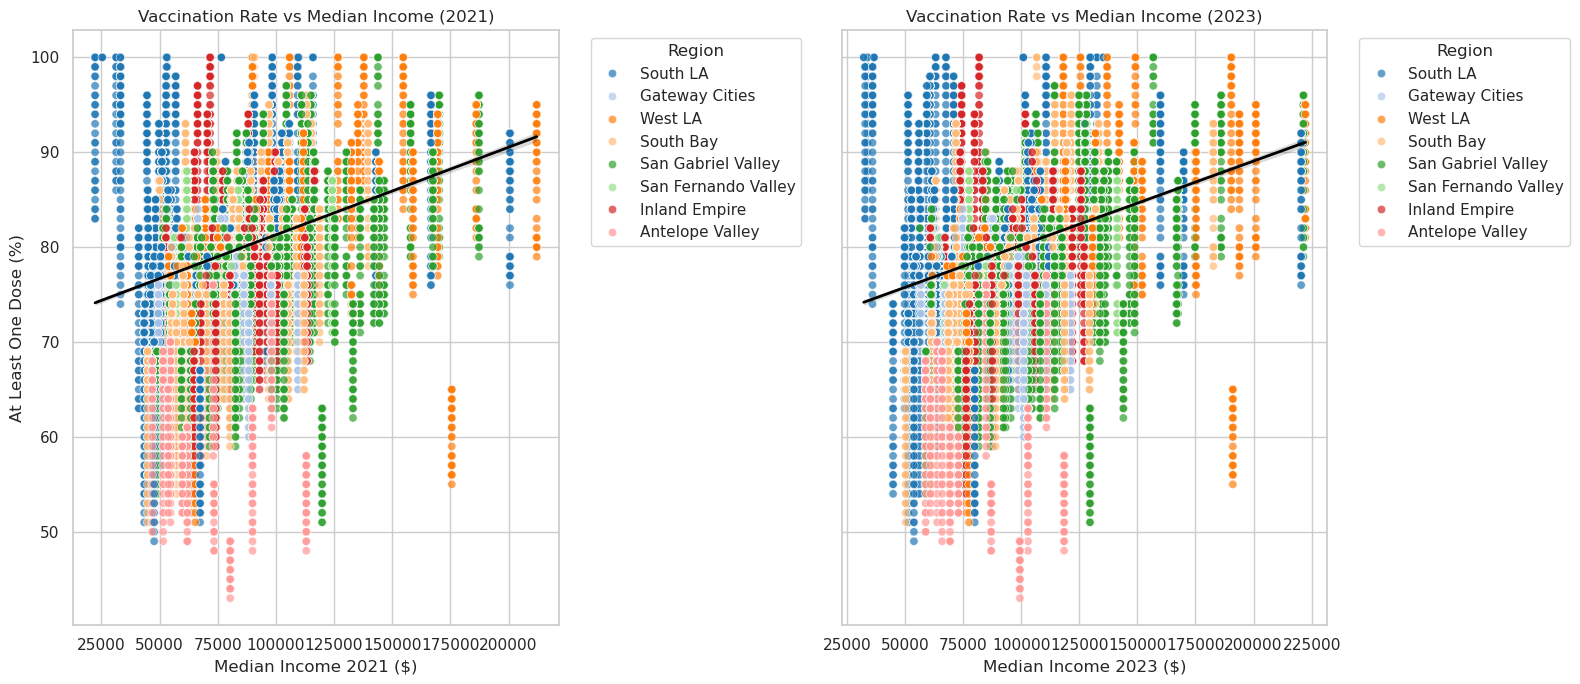

In [78]:
# --- 1. Convert median incomes to numeric ---
snapshot_with_income['median_income_2021'] = pd.to_numeric(
    snapshot_with_income['median_income_2021'].replace('[\$,]', '', regex=True),
    errors='coerce'
)
snapshot_with_income['median_income_2023'] = pd.to_numeric(
    snapshot_with_income['median_income_2023'].replace('[\$,]', '', regex=True),
    errors='coerce'
)

# --- 2. Cap vaccination percentages at 100 ---
snapshot_with_income['at_least_one_dose_percent'] = snapshot_with_income['at_least_one_dose_percent'].clip(upper=100)
snapshot_with_income['fully_vaccinated_percent'] = snapshot_with_income['fully_vaccinated_percent'].clip(upper=100)

# --- 3. Split datasets by year ---
df_2021 = snapshot_with_income[['zip', 'at_least_one_dose_percent', 'region', 'median_income_2021']].dropna()
df_2023 = snapshot_with_income[['zip', 'at_least_one_dose_percent', 'region', 'median_income_2023']].dropna()

# --- 4. Add small jitter to x for scatter plot ---
def add_jitter(series, jitter_amount=0.02):
    return series + np.random.uniform(-jitter_amount, jitter_amount, size=len(series))

df_2021['median_income_2021_jitter'] = add_jitter(df_2021['median_income_2021'])
df_2023['median_income_2023_jitter'] = add_jitter(df_2023['median_income_2023'])

# --- 5. Create side-by-side scatter plots with regression lines ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 2021 plot
sns.scatterplot(
    data=df_2021,
    x='median_income_2021_jitter',
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab20',
    ax=axes[0],
    alpha=0.7
)
sns.regplot(
    data=df_2021,
    x='median_income_2021',
    y='at_least_one_dose_percent',
    scatter=False,
    ax=axes[0],
    color='black',
    line_kws={'linewidth':2}
)
axes[0].set_title('Vaccination Rate vs Median Income (2021)')
axes[0].set_xlabel('Median Income 2021 ($)')
axes[0].set_ylabel('At Least One Dose (%)')
axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2023 plot
sns.scatterplot(
    data=df_2023,
    x='median_income_2023_jitter',
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab20',
    ax=axes[1],
    alpha=0.7
)
sns.regplot(
    data=df_2023,
    x='median_income_2023',
    y='at_least_one_dose_percent',
    scatter=False,
    ax=axes[1],
    color='black',
    line_kws={'linewidth':2}
)
axes[1].set_title('Vaccination Rate vs Median Income (2023)')
axes[1].set_xlabel('Median Income 2023 ($)')
axes[1].set_ylabel('')  # hide ylabel to avoid duplication
axes[1].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

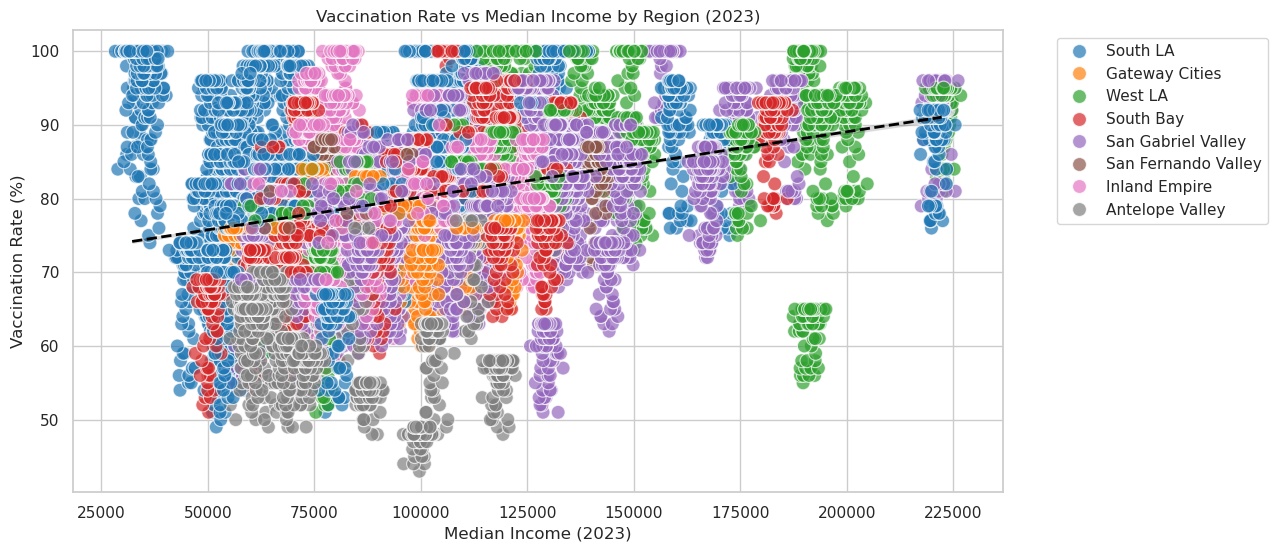

In [79]:
# Create jittered income column
snapshot_with_income['income_2023_jitter'] = (
    snapshot_with_income['median_income_2023'] +
    np.random.normal(0, 1500, size=len(snapshot_with_income))  # adjust spread if needed
)

plt.figure(figsize=(12,6))

# Scatter with jitter
sns.scatterplot(
    data=snapshot_with_income,
    x='income_2023_jitter',
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab10',
    s=100,
    alpha=0.7
)

# Regression line using real values
sns.regplot(
    data=snapshot_with_income,
    x='median_income_2023',
    y='at_least_one_dose_percent',
    scatter=False,
    color='black',
    line_kws={'linewidth':2, 'linestyle':'--'}
)

plt.xlabel('Median Income (2023)')
plt.ylabel('Vaccination Rate (%)')
plt.title('Vaccination Rate vs Median Income by Region (2023)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

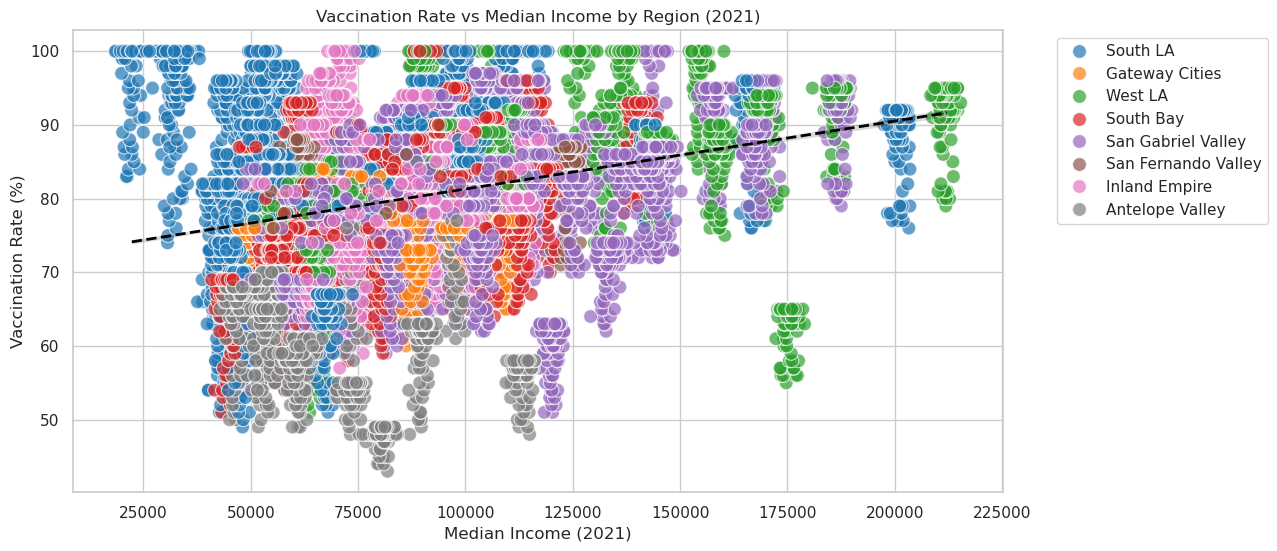

In [80]:
# Create jittered income column
snapshot_with_income['income_2021_jitter'] = (
    snapshot_with_income['median_income_2021'] +
    np.random.normal(0, 1500, size=len(snapshot_with_income))  # adjust spread if needed
)

plt.figure(figsize=(12,6))

# Scatter with jitter
sns.scatterplot(
    data=snapshot_with_income,
    x='income_2021_jitter',
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab10',
    s=100,
    alpha=0.7
)

# Regression line using real values
sns.regplot(
    data=snapshot_with_income,
    x='median_income_2021',
    y='at_least_one_dose_percent',
    scatter=False,
    color='black',
    line_kws={'linewidth':2, 'linestyle':'--'}
)

plt.xlabel('Median Income (2021)')
plt.ylabel('Vaccination Rate (%)')
plt.title('Vaccination Rate vs Median Income by Region (2021)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

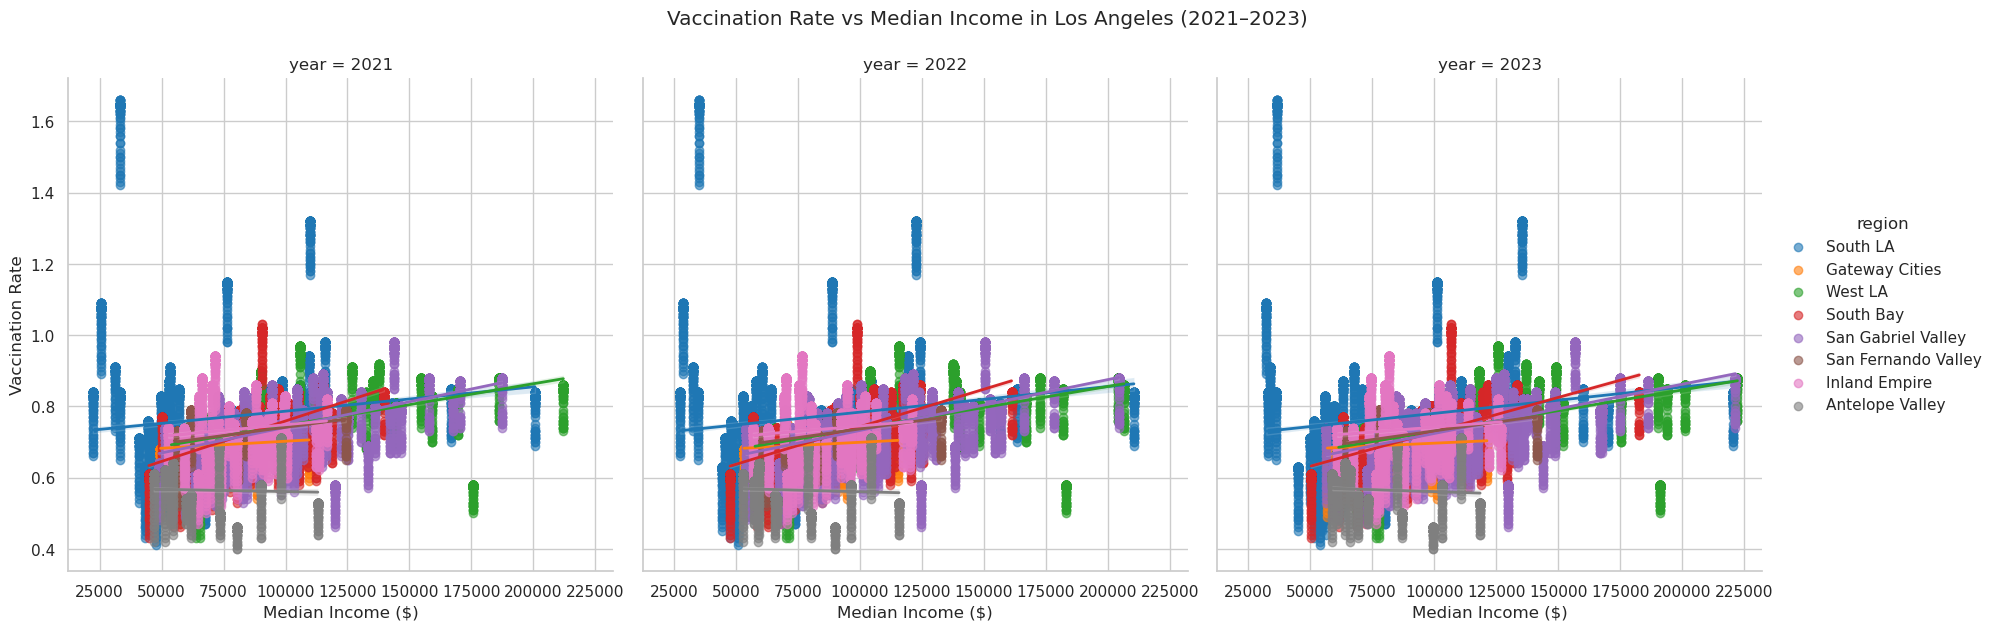

In [82]:
# --- Prepare long format dataset ---
income_long = snapshot_with_income.melt(
    id_vars=['zip', 'region', 'vax_rate'],
    value_vars=['median_income_2021', 'median_income_2022', 'median_income_2023'],
    var_name='year',
    value_name='income_value'   # changed name to avoid conflict
)

# Extract year number
income_long['year'] = income_long['year'].str.extract('(\d+)')

# --- Plot ---
sns.set(style="whitegrid")

g = sns.lmplot(
    data=income_long,
    x="income_value",
    y="vax_rate",
    hue="region",
    col="year",
    palette="tab10",
    height=6,
    aspect=1,
    scatter_kws={"alpha":0.6},
    line_kws={"linewidth":2}
)

g.set_axis_labels("Median Income ($)", "Vaccination Rate")
g.fig.suptitle("Vaccination Rate vs Median Income in Los Angeles (2021–2023)", y=1.05)

plt.show()

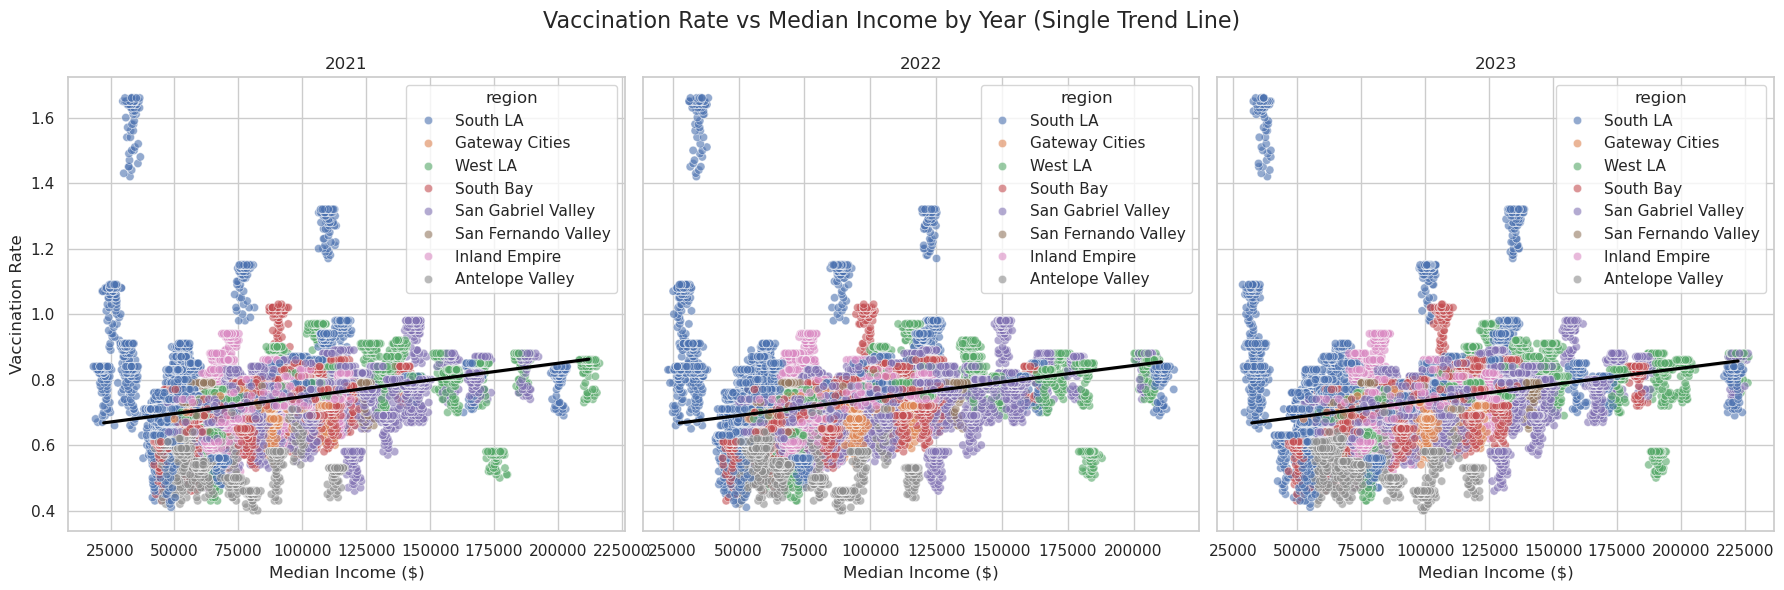

In [83]:
sns.set(style="whitegrid")

# --- Create jittered income columns ---
snapshot_with_income['income_2021_jitter'] = (
    snapshot_with_income['median_income_2021'] +
    np.random.normal(0, 1500, len(snapshot_with_income))
)

snapshot_with_income['income_2022_jitter'] = (
    snapshot_with_income['median_income_2022'] +
    np.random.normal(0, 1500, len(snapshot_with_income))
)

snapshot_with_income['income_2023_jitter'] = (
    snapshot_with_income['median_income_2023'] +
    np.random.normal(0, 1500, len(snapshot_with_income))
)

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

years = ['2021','2022','2023']

for i, year in enumerate(years):

    income_col = f'median_income_{year}'
    jitter_col = f'income_{year}_jitter'
    
    # Scatter with jitter
    sns.scatterplot(
        data=snapshot_with_income,
        x=jitter_col,
        y='vax_rate',
        hue='region',
        alpha=0.6,
        ax=axes[i]
    )
    
    # Regression line using real values
    sns.regplot(
        data=snapshot_with_income,
        x=income_col,
        y='vax_rate',
        scatter=False,
        color='black',
        ax=axes[i]
    )

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Median Income ($)")

axes[0].set_ylabel("Vaccination Rate")

plt.suptitle("Vaccination Rate vs Median Income by Year (Single Trend Line)", fontsize=16)

plt.tight_layout()
plt.show()

In [59]:
snapshot_with_income["date"].unique()

<DatetimeArray>
['2021-08-17 00:00:00', '2021-08-24 00:00:00', '2021-08-31 00:00:00',
 '2021-09-07 00:00:00', '2021-09-14 00:00:00', '2021-09-21 00:00:00',
 '2021-09-28 00:00:00', '2021-10-05 00:00:00', '2021-10-12 00:00:00',
 '2021-10-19 00:00:00', '2021-10-26 00:00:00', '2021-11-02 00:00:00',
 '2021-11-09 00:00:00', '2021-11-16 00:00:00', '2021-11-23 00:00:00',
 '2021-11-30 00:00:00', '2021-12-07 00:00:00', '2021-12-14 00:00:00',
 '2021-12-21 00:00:00', '2021-12-28 00:00:00', '2022-01-04 00:00:00',
 '2022-01-11 00:00:00', '2022-01-18 00:00:00', '2022-01-25 00:00:00',
 '2022-02-01 00:00:00', '2022-02-08 00:00:00', '2022-02-15 00:00:00',
 '2022-02-22 00:00:00', '2022-03-01 00:00:00', '2022-03-08 00:00:00',
 '2022-03-15 00:00:00', '2022-03-22 00:00:00', '2022-03-29 00:00:00',
 '2022-04-05 00:00:00', '2022-04-12 00:00:00', '2022-04-19 00:00:00',
 '2022-04-26 00:00:00', '2022-05-03 00:00:00', '2022-05-10 00:00:00',
 '2022-05-17 00:00:00', '2022-05-24 00:00:00', '2022-05-31 00:00:00',
 '20

# List of years you want to plot
years = ['2021', '2022', '2023']

for year in years:
    # Filter the correct median income column just in case (not used for vax here)
    if year == '2022' and 'median_income_2022' not in snapshot_with_income.columns:
        # Create 2022 median income if missing
        snapshot_with_income['median_income_2022'] = (
            snapshot_with_income['median_income_2021'] + snapshot_with_income['median_income_2023']
        ) / 2

    # Compute average vaccination rate by region
    region_vax = snapshot_with_income.groupby('region')['vax_rate'].mean().sort_values()

    # Plot
    plt.figure(figsize=(10,6))
    sns.barplot(
        x=region_vax.values,
        y=region_vax.index,
        palette="mako"
    )

    # Add value labels on bars
    for i, v in enumerate(region_vax.values):
        plt.text(v + 0.005, i, f"{v:.2f}", va='center')

    plt.xlabel("Average Vaccination Rate")
    plt.ylabel("Region")
    plt.title(f"Average Vaccination Rate by Region ({year})")
    plt.xlim(0, 1)  # assuming vax_rate is 0-1
    plt.show()

# Years we want to plot
years = ['2021', '2022', '2023']

for year in years:
    # Select the appropriate median income column
    if year == '2021':
        income_col = 'median_income_2021'
    elif year == '2022':
        income_col = 'median_income_2022'
    else:  # 2023
        income_col = 'median_income_2023'

    # Compute average median income by region
    region_income = snapshot_with_income.groupby('region')[income_col].mean().sort_values()

    # Plot
    plt.figure(figsize=(10,6))
    sns.barplot(
        x=region_income.values,
        y=region_income.index,
        palette="mako"
    )

    # Annotate each bar with the income value
    for i, v in enumerate(region_income.values):
        plt.text(v + 500, i, f"${v:,.0f}", va='center')  # add $ sign, round to whole number

    plt.xlabel("Average Median Household Income ($)")
    plt.ylabel("Region")
    plt.title(f"Average Median Household Income by Region ({year})")
    plt.show()

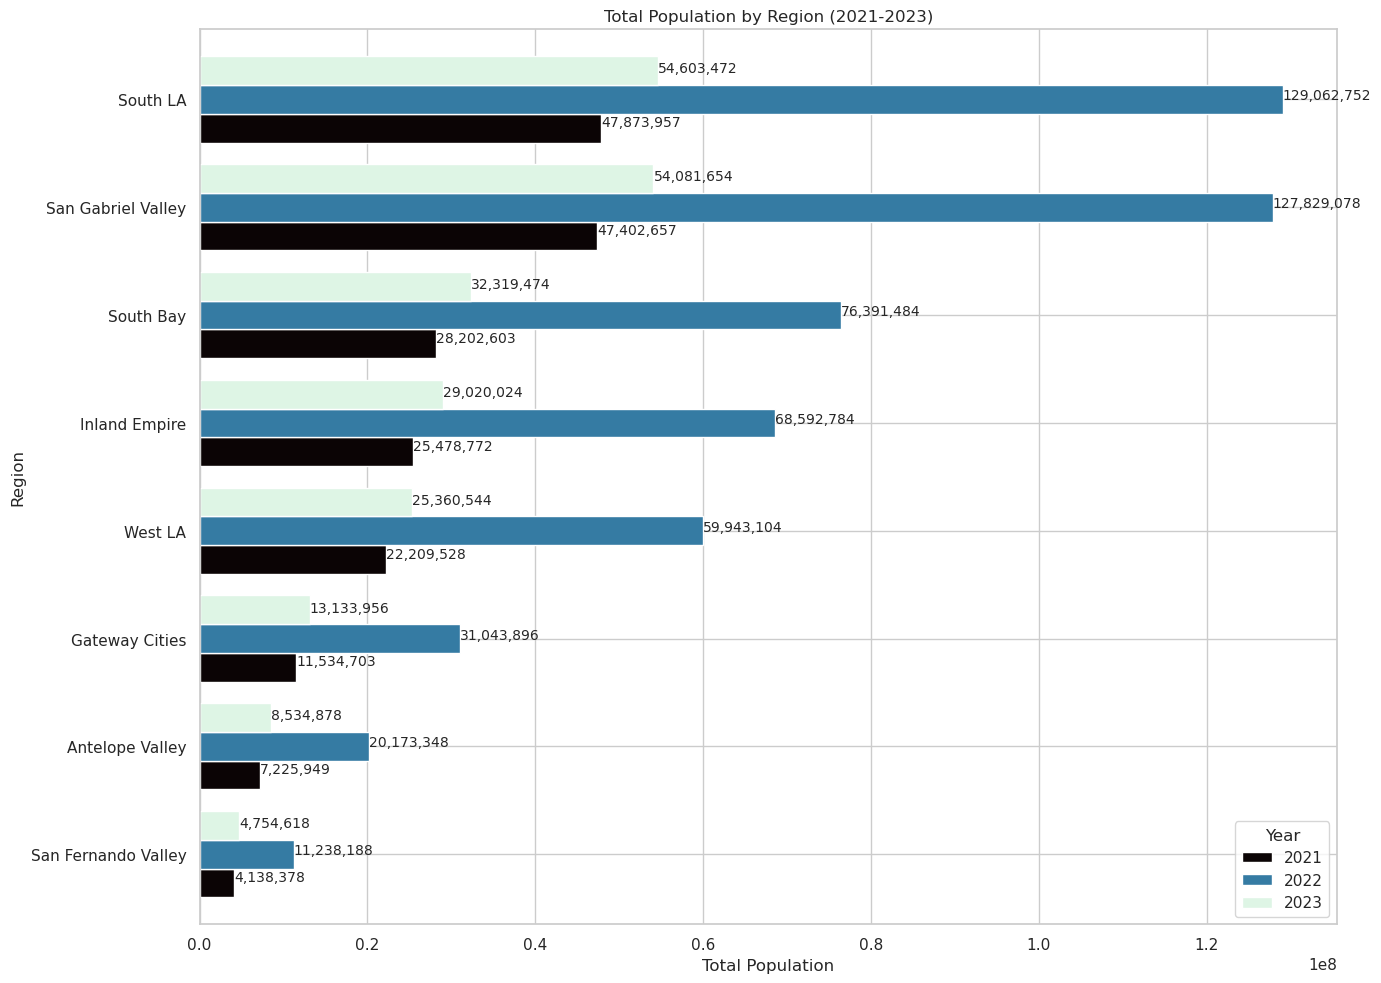

In [73]:
# Ensure years are strings for plotting
snapshot_with_income['year'] = snapshot_with_income['year'].astype(str)

# Group by region and year, sum population
region_population = (
    snapshot_with_income
    .groupby(['region', 'year'], as_index=False)['population']
    .sum()
)

# Pivot for grouped bar chart
region_pop_pivot = region_population.pivot(index='region', columns='year', values='population')

# Sort regions by 2023 population (or choose whichever year you like)
region_pop_pivot = region_pop_pivot.sort_values(by='2023', ascending=True)

# Plot grouped bar chart
region_pop_pivot.plot(
    kind='barh',
    figsize=(14, 10),
    width=0.8,
    cmap='mako'
)

# Add value labels on the bars
for i, region in enumerate(region_pop_pivot.index):
    for j, year in enumerate(region_pop_pivot.columns):
        val = region_pop_pivot.loc[region, year]
        plt.text(
            val + 1000,  # shift slightly to the right
            i - 0.25 + j*0.25,  # stagger vertically within the bar group
            f"{int(val):,}",
            fontsize=10
        )

plt.xlabel("Total Population")
plt.ylabel("Region")
plt.title("Total Population by Region (2021-2023)")
plt.legend(title='Year')
plt.tight_layout()
plt.show()

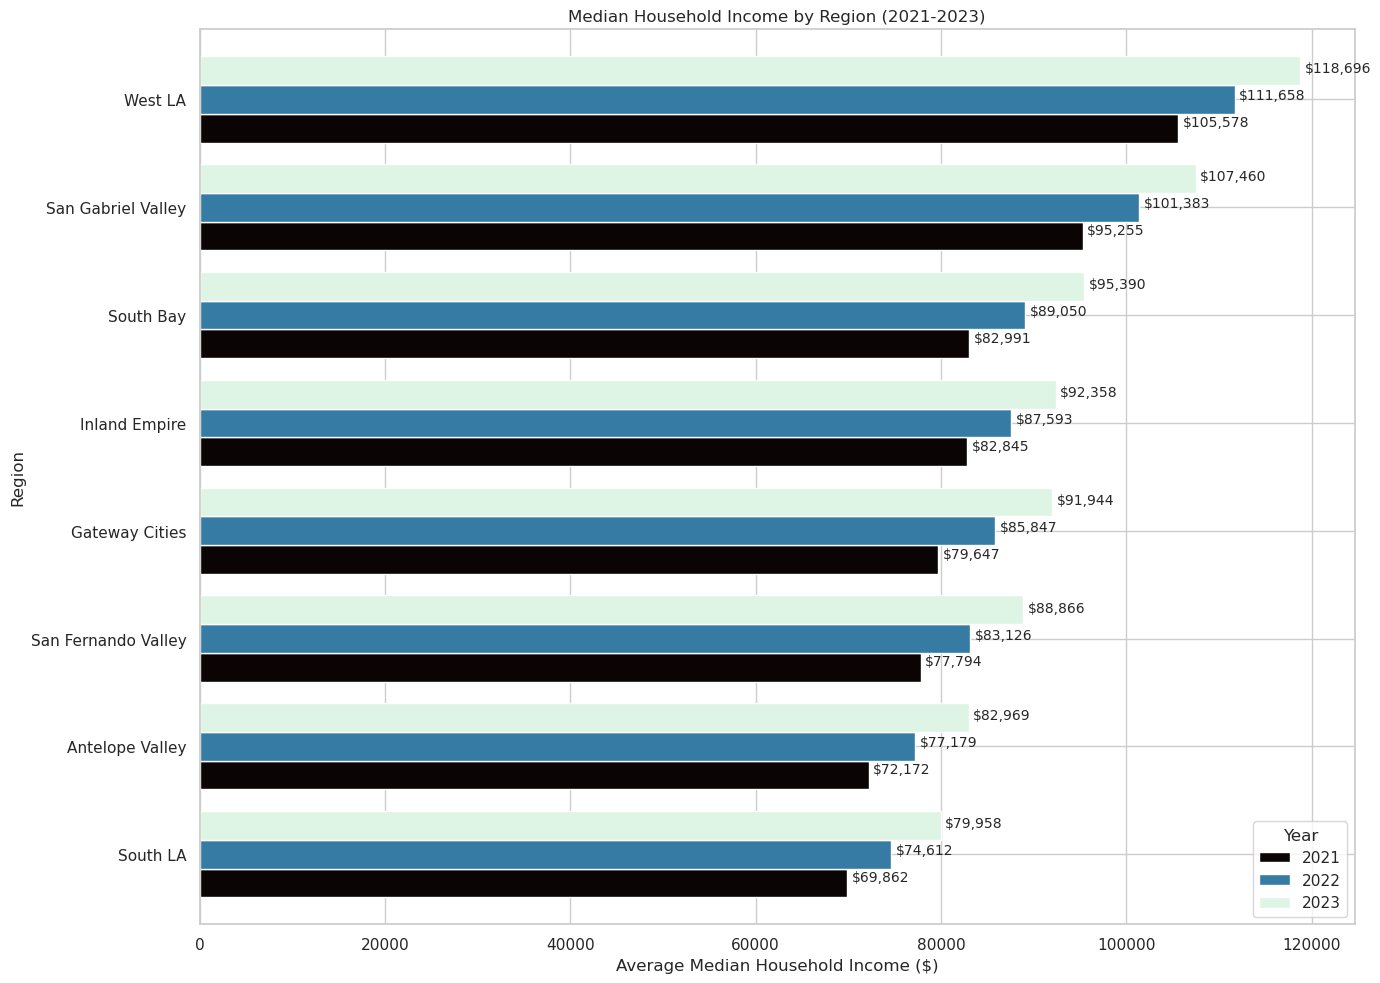

In [75]:
# Ensure 'year' is a string
snapshot_with_income['year'] = snapshot_with_income['year'].astype(str)

# --- Median Income by Region ---
region_income = (
    snapshot_with_income
    .groupby(['region', 'year'], as_index=False)['median_income']
    .mean()
)
region_income_pivot = region_income.pivot(index='region', columns='year', values='median_income')
region_income_pivot = region_income_pivot.sort_values(by='2023', ascending=True)

plt.figure(figsize=(14, 10))
region_income_pivot.plot(
    kind='barh',
    width=0.8,
    cmap='mako',
    ax=plt.gca()
)
for i, region in enumerate(region_income_pivot.index):
    for j, year in enumerate(region_income_pivot.columns):
        val = region_income_pivot.loc[region, year]
        plt.text(
            val + 500,  # small offset for readability
            i - 0.25 + j*0.25,
            f"${int(val):,}",
            fontsize=10
        )
plt.xlabel("Average Median Household Income ($)")
plt.ylabel("Region")
plt.title("Median Household Income by Region (2021-2023)")
plt.legend(title='Year')
plt.tight_layout()
plt.show()

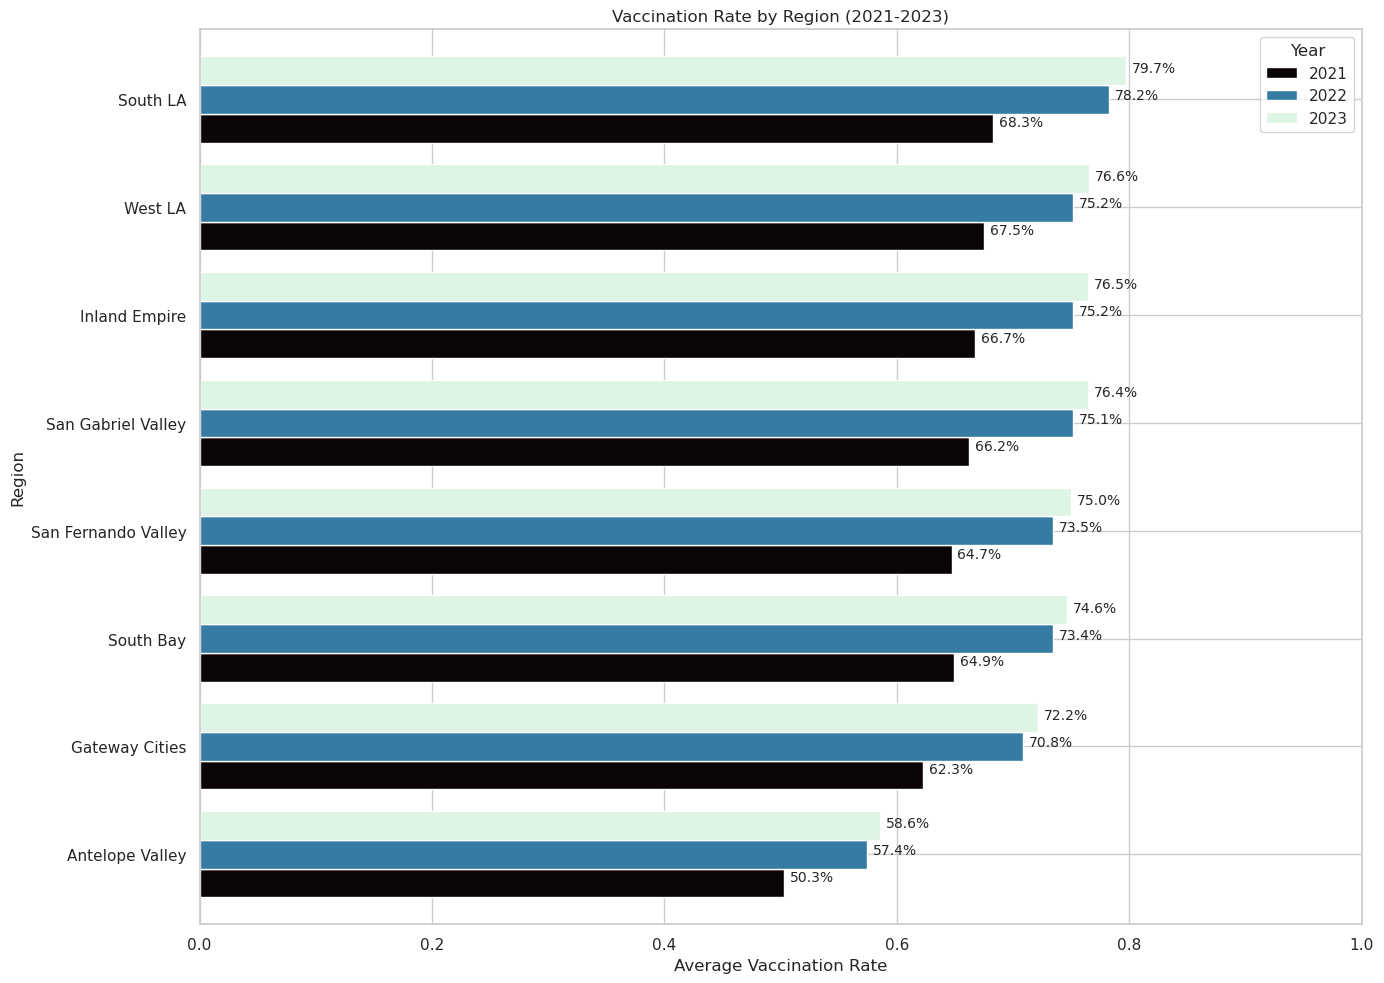

In [77]:
# --- Vaccination Rate by Region (same style as income) ---
region_vax = (
    snapshot_with_income
    .groupby(['region', 'year'], as_index=False)['vax_rate']
    .mean()
)
region_vax_pivot = region_vax.pivot(index='region', columns='year', values='vax_rate')
region_vax_pivot = region_vax_pivot.sort_values(by='2023', ascending=True)

plt.figure(figsize=(14, 10))
region_vax_pivot.plot(
    kind='barh',
    width=0.8,
    cmap='mako',  # same colormap as median income
    ax=plt.gca()
)
for i, region in enumerate(region_vax_pivot.index):
    for j, year in enumerate(region_vax_pivot.columns):
        val = region_vax_pivot.loc[region, year]
        plt.text(
            val + 0.005,  # small offset for readability
            i - 0.25 + j*0.25,
            f"{val:.1%}",  # format as percentage
            fontsize=10
        )
plt.xlabel("Average Vaccination Rate")
plt.ylabel("Region")
plt.title("Vaccination Rate by Region (2021-2023)")
plt.xlim(0, 1)  # assuming vax_rate is 0-1
plt.legend(title='Year')
plt.tight_layout()
plt.show()